<a href="https://colab.research.google.com/github/jatin-reddy/Semantic_Similarity_NLP/blob/main/Semantic_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

100%|██████████| 20.8M/20.8M [00:02<00:00, 10.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_path = "/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2"
df_path = os.path.join(df_path, "questions.csv")
df = pd.read_csv(df_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [4]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
print(df.isnull().sum())
df = df.dropna()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [6]:
print(df.isnull().sum())

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


In [7]:
print(df['is_duplicate'].value_counts())
print(df['is_duplicate'].value_counts(normalize=True))

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    0.630749
1    0.369251
Name: proportion, dtype: float64


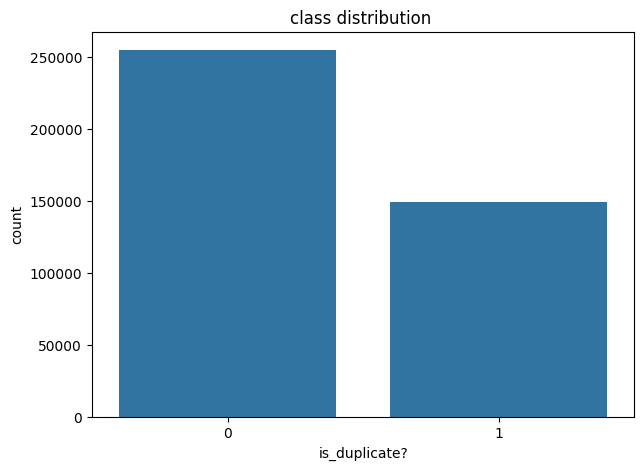

In [8]:
# 0 = not similar, 1 = similar
plt.figure(figsize=(7, 5))
sns.countplot(x='is_duplicate', data=df)
plt.title('class distribution ')
plt.xlabel('is_duplicate?')
plt.ylabel('count')
plt.show()

In [9]:
# We'll use a small random sample to work with
sample_size = 20000
df_sample = df.sample(n=sample_size, random_state=42)
df_sample.head()

,id,qid1,qid2,question1,question2,is_duplicate
371032,371032,726051,726052,Do people realize that you can send marijuana ...,How do you send weed through the mail?,0
263498,263498,518455,518456,How can rock music be brought back?,What would it take for rock music to make a co...,1
111008,111008,220125,220126,Why does one feel relaxed after smoking a join...,How do I sober up quickly after smoking weed/m...,0
75665,75665,150351,150352,How to gain weight ?,How do I gain weight fast but still be healthy?,1
52376,52376,104229,104230,Is porn bad for men?,Can I become a porn fan without getting addicted?,0


In [10]:
!pip install -U sentence-transformers

In [11]:
# Embeddings using Sentence-BERT (bi-encoders: sentence-transformers/all-MiniLM-L6-v2)
# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

from sentence_transformers import SentenceTransformer
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

unique_questions_set = set(df_sample['question1']) | set(df_sample['question2'])
unique_questions_list = list(unique_questions_set)


print(f"sample question pairs = {len(df_sample)}") #20000
print(f"sample unique questions = {len(unique_questions_list)}")

unique_questions_embeddings = model.encode(unique_questions_list)
print(f"unique questions embeddings shape = {unique_questions_embeddings.shape}")

sample question pairs = 20000
sample unique questions = 37770
unique questions embeddings shape = (37770, 384)


In [13]:
embedding_map = {question: embedding for question, embedding in zip(unique_questions_list, unique_questions_embeddings)}


df_sample['embedding1'] = df_sample['question1'].map(embedding_map)
df_sample['embedding2'] = df_sample['question2'].map(embedding_map)

In [14]:
print(df_sample.head())

            id    qid1    qid2  \
371032  371032  726051  726052   
263498  263498  518455  518456   
111008  111008  220125  220126   
75665    75665  150351  150352   
52376    52376  104229  104230   

                                                question1  \
371032  Do people realize that you can send marijuana ...   
263498                How can rock music be brought back?   
111008  Why does one feel relaxed after smoking a join...   
75665                                How to gain weight ?   
52376                                Is porn bad for men?   

                                                question2  is_duplicate  \
371032             How do you send weed through the mail?             0   
263498  What would it take for rock music to make a co...             1   
111008  How do I sober up quickly after smoking weed/m...             0   
75665     How do I gain weight fast but still be healthy?             1   
52376   Can I become a porn fan without getting addic